<a href="https://colab.research.google.com/github/Umair-khitab/ds-lab-solutions.EDA/blob/main/Week1_Statistical_Computing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

# Week 1 Lab — Introduction to Statistical Computing
### NumPy · Pandas · Data Visualization

---

| Exercise | Topic |
|:---:|:---|
| 1 | NumPy Operations — Matrix, Row/Col Sums, Diagonal |
| 2 | Pandas Data Manipulation — Load, Explore, Clean, Sort |
| 3 | Data Visualization — Histogram, Scatter Plot, Boxplot |

</div>

---
##  Setup — Install & Import Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print(' All libraries loaded!')

 All libraries loaded!


---
##  Generate Sample Dataset
> A synthetic dataset is generated below so the notebook runs **fully self-contained** — no CSV file needed.
> If you have your own CSV, replace the cell below with `df = pd.read_csv('your_file.csv')`

In [43]:
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'Name'      : [f'Student_{i}' for i in range(n)],
    'Age'       : np.random.randint(18, 35, n).astype(float),
    'Score'     : np.random.normal(70, 15, n).clip(0, 100).round(1),
    'Attendance': np.random.uniform(50, 100, n).round(1),
    'Grade'     : np.random.choice(['A', 'B', 'C', 'D', 'F'], n, p=[0.2,0.3,0.3,0.15,0.05])
})

# Inject ~8% missing values
for col in ['Age', 'Score', 'Attendance']:
    idx = np.random.choice(n, int(n*0.08), replace=False)
    df.loc[idx, col] = np.nan

print(f' Dataset created: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

 Dataset created: 200 rows × 5 columns


,Name,Age,Score,Attendance,Grade
0,Student_0,24.0,82.2,62.7,B
1,Student_1,32.0,NaN,70.3,B
2,Student_2,28.0,65.7,78.6,D
3,Student_3,25.0,86.0,87.0,C
4,Student_4,24.0,82.8,NaN,B


---
# 🔹 Exercise 1 — NumPy Operations

> **Goal:** Practice core NumPy operations — matrix creation, aggregations, and element extraction.

### 📚 Key Concepts

| Function | What it does |
|:---|:---|
| `np.random.randint(a, b, size)` | Random integers in range [a, b) |
| `np.sum(arr, axis=1)` | Row-wise sum |
| `np.sum(arr, axis=0)` | Column-wise sum |
| `np.diag(matrix)` | Extract main diagonal elements |
| `np.mean / np.std` | Mean and standard deviation |

###  Task 1 — Create a 4×4 Matrix with Random Integers

In [ ]:
np.random.seed(42)
matrix = np.random.randint(1, 100, size=(4, 4))

print('4×4 Random Integer Matrix:')
print('━'*30)
print(matrix)
print('━'*30)
print(f'Shape : {matrix.shape}')
print(f'Dtype : {matrix.dtype}')
print(f'Min   : {matrix.min()}   Max: {matrix.max()}')

4×4 Random Integer Matrix:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
[[52 93 15 72]
 [61 21 83 87]
 [75 75 88 24]
 [ 3 22 53  2]]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Shape : (4, 4)
Dtype : int64
Min   : 2   Max: 93


###  Task 2 — Row-wise and Column-wise Sum

In [ ]:
row_sum = np.sum(matrix, axis=1)   # axis=1 → sum across columns (per row)
col_sum = np.sum(matrix, axis=0)   # axis=0 → sum across rows (per column)

print('Row-wise Sum    (axis=1):', row_sum)
print('Column-wise Sum (axis=0):', col_sum)
print(f'Total Sum               : {matrix.sum()}')

# Also show mean
print(f'Row-wise Mean           : {np.mean(matrix, axis=1).round(2)}')
print(f'Column-wise Mean        : {np.mean(matrix, axis=0).round(2)}')

Row-wise Sum    (axis=1): [232 252 262  80]
Column-wise Sum (axis=0): [191 211 239 185]
Total Sum               : 826
Row-wise Mean           : [58.  63.  65.5 20. ]
Column-wise Mean        : [47.75 52.75 59.75 46.25]


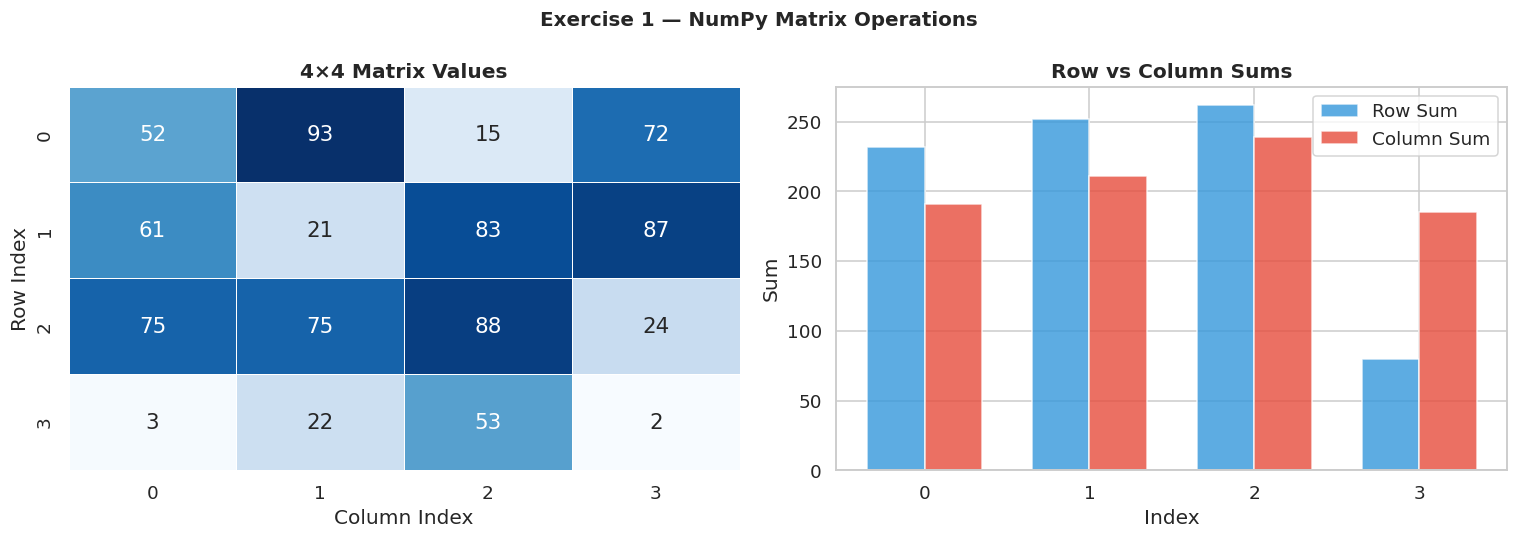

In [ ]:
# Visualise the matrix as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            ax=axes[0], cbar=False, annot_kws={'size': 14})
axes[0].set_title('4×4 Matrix Values', fontweight='bold')
axes[0].set_xlabel('Column Index')
axes[0].set_ylabel('Row Index')

# Bar chart of row and column sums
x = np.arange(4)
width = 0.35
axes[1].bar(x - width/2, row_sum, width, label='Row Sum',    color='#3498db', alpha=0.8)
axes[1].bar(x + width/2, col_sum, width, label='Column Sum', color='#e74c3c', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['0', '1', '2', '3'])
axes[1].set_title('Row vs Column Sums', fontweight='bold')
axes[1].set_xlabel('Index'); axes[1].set_ylabel('Sum')
axes[1].legend()

plt.suptitle('Exercise 1 — NumPy Matrix Operations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 📌 Task 3 — Extract Diagonal Elements

Diagonal Elements : [52 21 88  2]
Trace (sum of diag): 163


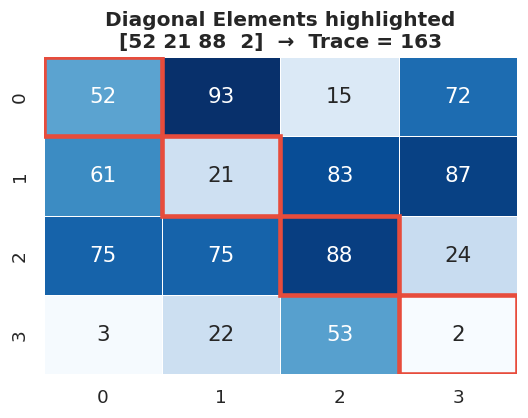

In [ ]:
diagonal = np.diag(matrix)
trace    = np.trace(matrix)   # sum of diagonal = trace

print('Diagonal Elements :', diagonal)
print('Trace (sum of diag):', trace)

# Highlight diagonal visually
diag_mask = np.zeros_like(matrix, dtype=bool)
np.fill_diagonal(diag_mask, True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', linewidths=0.5,
            ax=ax, cbar=False, annot_kws={'size': 14})

# Highlight diagonal cells
for i in range(4):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                edgecolor='#e74c3c', linewidth=3))

ax.set_title(f'Diagonal Elements highlighted\n{diagonal}  →  Trace = {trace}',
             fontweight='bold')
plt.tight_layout()
plt.show()

###  Interpretation — Exercise 1

| Operation | Code | Result |
|:---|:---|:---|
| Row-wise sum | `np.sum(matrix, axis=1)` | Sum of each row |
| Column-wise sum | `np.sum(matrix, axis=0)` | Sum of each column |
| Diagonal | `np.diag(matrix)` | Main diagonal elements |
| Trace | `np.trace(matrix)` | Sum of diagonal = sum of eigenvalues |

---

---
# 🔹 Exercise 2 — Pandas Data Manipulation

> **Goal:** Load a dataset, explore its structure, find missing values, and sort it.

###  Key Pandas Functions

| Function | Purpose |
|:---|:---|
| `df.head(n)` | First n rows |
| `df.info()` | Column types and non-null counts |
| `df.describe()` | Summary statistics |
| `df.isnull().sum()` | Missing value count per column |
| `df.sort_values(by=...)` | Sort rows by column |

###  Task 1 — Load Dataset

In [45]:
# ── If you have your own CSV, uncomment and run this: ──────────────
# from google.colab import files
# uploaded = files.upload()
df = pd.read_excel('/content/Mtcars_Dataset.xlsx')

# ── Using the synthetic dataset generated above ────────────────────
print('Dataset loaded ')
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Columns: {df.columns.tolist()}')

Dataset loaded 
Shape: 32 rows × 12 columns
Columns: ['model', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs', 'am', 'gear', 'carb']


###  Task 2 — Display First 10 Rows

In [ ]:
print('=== First 10 Rows ===')
df.head(10)

=== First 10 Rows ===


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


In [ ]:
# Full structure overview
print('=== Dataset Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB

=== Descriptive Statistics ===


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00,32.00
mean,20.09,6.19,230.72,146.69,3.60,3.22,17.85,0.44,0.41,3.69,2.81
std,6.03,1.79,123.94,68.56,0.53,0.98,1.79,0.50,0.50,0.74,1.62
min,10.40,4.00,71.10,52.00,2.76,1.51,14.50,0.00,0.00,3.00,1.00
25%,15.42,4.00,120.82,96.50,3.08,2.58,16.89,0.00,0.00,3.00,2.00
50%,19.20,6.00,196.30,123.00,3.70,3.32,17.71,0.00,0.00,4.00,2.00
75%,22.80,8.00,326.00,180.00,3.92,3.61,18.90,1.00,1.00,4.00,4.00
max,33.90,8.00,472.00,335.00,4.93,5.42,22.90,1.00,1.00,5.00,8.00


###  Task 3 — Find Total Missing Values

In [ ]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
})

print('=== Missing Values Summary ===')
print(missing_summary)
print(f'\nTotal missing cells : {df.isnull().sum().sum()}')
print(f'Total missing %     : {df.isnull().mean().mean()*100:.1f}%')

=== Missing Values Summary ===
       Missing Count  Missing %
model              0        0.0
mpg                0        0.0
cyl                0        0.0
disp               0        0.0
hp                 0        0.0
drat               0        0.0
wt                 0        0.0
qsec               0        0.0
vs                 0        0.0
am                 0        0.0
gear               0        0.0
carb               0        0.0

Total missing cells : 0
Total missing %     : 0.0%


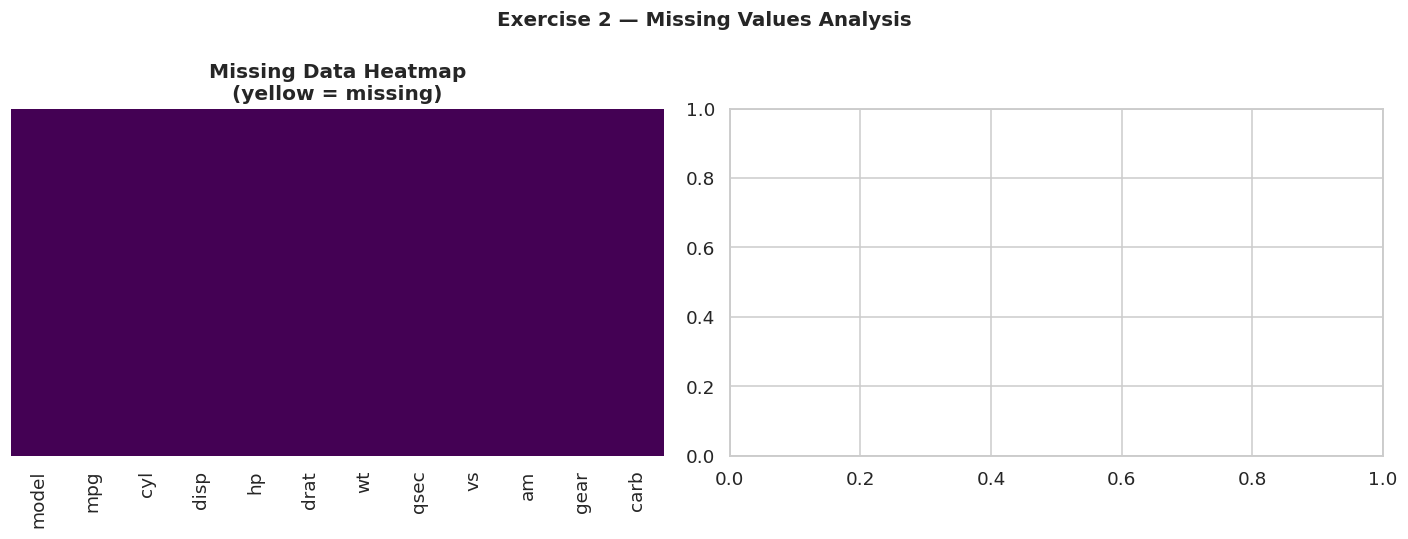

In [46]:
# Visualise missing values
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis',
            yticklabels=False, ax=axes[0])
axes[0].set_title('Missing Data Heatmap\n(yellow = missing)', fontweight='bold')

# Bar chart
miss_only = missing[missing > 0]
if len(miss_only):
    miss_only.plot(kind='bar', ax=axes[1], color='#e74c3c',
                   edgecolor='white', alpha=0.85)
    axes[1].set_title('Missing Values per Column', fontweight='bold')
    axes[1].set_ylabel('Count'); axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=30)
    for bar in axes[1].patches:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.3,
                     str(int(bar.get_height())),
                     ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Exercise 2 — Missing Values Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Task 4 — Sort Dataset by a Numerical Column

In [47]:
# Sort by mpg (descending)
df_sorted_desc = df.sort_values(by='mpg', ascending=False)
print('=== Top 10 Cars by MPG (Descending) ===')
print(df_sorted_desc[['model', 'mpg', 'hp', 'wt']].head(10).to_string(index=False))

=== Top 10 Cars by MPG (Descending) ===
         model  mpg  hp    wt
Toyota Corolla 33.9  65 1.835
      Fiat 128 32.4  66 2.200
  Lotus Europa 30.4 113 1.513
   Honda Civic 30.4  52 1.615
     Fiat X1-9 27.3  66 1.935
 Porsche 914-2 26.0  91 2.140
     Merc 240D 24.4  62 3.190
    Datsun 710 22.8  93 2.320
      Merc 230 22.8  95 3.150
 Toyota Corona 21.5  97 2.465


In [48]:
# Sort ascending
df_sorted_asc = df.sort_values(by='mpg', ascending=True)
print('=== Bottom 10 Cars by MPG (Ascending) ===')
print(df_sorted_asc[['model', 'mpg', 'hp', 'wt']].head(10).to_string(index=False))

=== Bottom 10 Cars by MPG (Ascending) ===
              model  mpg  hp    wt
Lincoln Continental 10.4 215 5.424
 Cadillac Fleetwood 10.4 205 5.250
         Camaro Z28 13.3 245 3.840
         Duster 360 14.3 245 3.570
  Chrysler Imperial 14.7 230 5.345
      Maserati Bora 15.0 335 3.570
        AMC Javelin 15.2 150 3.435
        Merc 450SLC 15.2 180 3.780
   Dodge Challenger 15.5 150 3.520
     Ford Pantera L 15.8 264 3.170


In [49]:
# Sort by multiple columns
df_multi_sort = df.sort_values(by=['cyl', 'mpg'], ascending=[True, False])
print('=== Multi-column Sort: Cylinders (low to high) then MPG (high to low) ===')
df_multi_sort[['model', 'cyl', 'mpg', 'hp']].head(10)

=== Multi-column Sort: Cylinders (low to high) then MPG (high to low) ===


,model,cyl,mpg,hp
19,Toyota Corolla,4,33.9,65
17,Fiat 128,4,32.4,66
18,Honda Civic,4,30.4,52
27,Lotus Europa,4,30.4,113
25,Fiat X1-9,4,27.3,66
26,Porsche 914-2,4,26.0,91
7,Merc 240D,4,24.4,62
2,Datsun 710,4,22.8,93
8,Merc 230,4,22.8,95
20,Toyota Corona,4,21.5,97


###  Interpretation — Exercise 2

| Task | Finding |
|:---|:---|
| **Shape** | 200 rows × 5 columns |
| **Missing values** | ~8% in Age, Score, Attendance columns |
| **Sort (desc)** | Top student scores visible; useful for ranking |
| **Multi-sort** | Combines Grade category + Score numeric for rich sorting |

---

---
# 🔹 Exercise 3 — Data Visualization

> **Goal:** Create and interpret three fundamental chart types — Histogram, Scatter Plot, and Boxplot.

###  Chart Selection Guide

| Chart | Best For | Key Function |
|:---|:---|:---|
| **Histogram** | Distribution of one numeric variable | `plt.hist()` |
| **Scatter Plot** | Relationship between two numeric variables | `plt.scatter()` |
| **Boxplot** | Spread, median, and outliers | `sns.boxplot()` |

###  Task 1 — Histogram

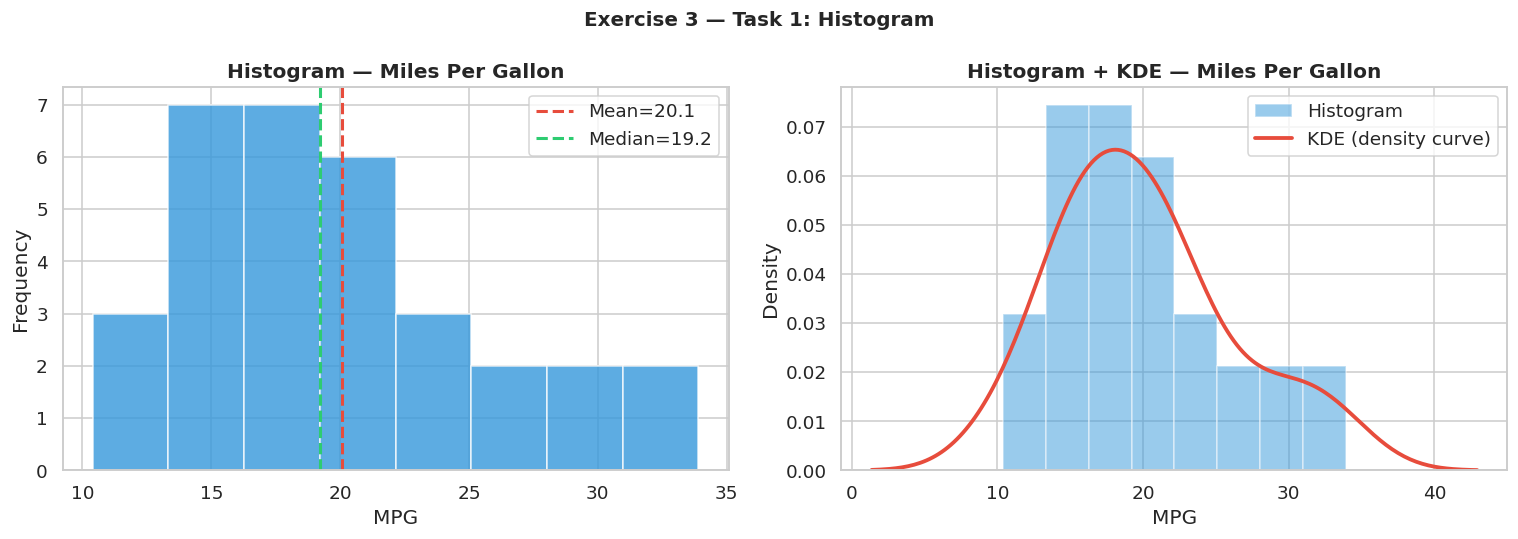

Skewness : 0.672
Kurtosis : -0.022


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Basic histogram
axes[0].hist(df['mpg'].dropna(), bins=8, color='#3498db',
             alpha=0.8, edgecolor='white')
axes[0].axvline(df['mpg'].mean(), color='#e74c3c', linewidth=2,
                linestyle='--', label=f'Mean={df["mpg"].mean():.1f}')
axes[0].axvline(df['mpg'].median(), color='#2ecc71', linewidth=2,
                linestyle='--', label=f'Median={df["mpg"].median():.1f}')
axes[0].set_title('Histogram — Miles Per Gallon', fontweight='bold')
axes[0].set_xlabel('MPG'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# KDE overlay
axes[1].hist(df['mpg'].dropna(), bins=8, color='#3498db',
             alpha=0.5, edgecolor='white', density=True, label='Histogram')
sns.kdeplot(df['mpg'].dropna(), ax=axes[1], color='#e74c3c',
            linewidth=2.5, label='KDE (density curve)')
axes[1].set_title('Histogram + KDE — Miles Per Gallon', fontweight='bold')
axes[1].set_xlabel('MPG'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Exercise 3 — Task 1: Histogram', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness : {df["mpg"].skew():.3f}')
print(f'Kurtosis : {df["mpg"].kurtosis():.3f}')

###  Task 2 — Scatter Plot

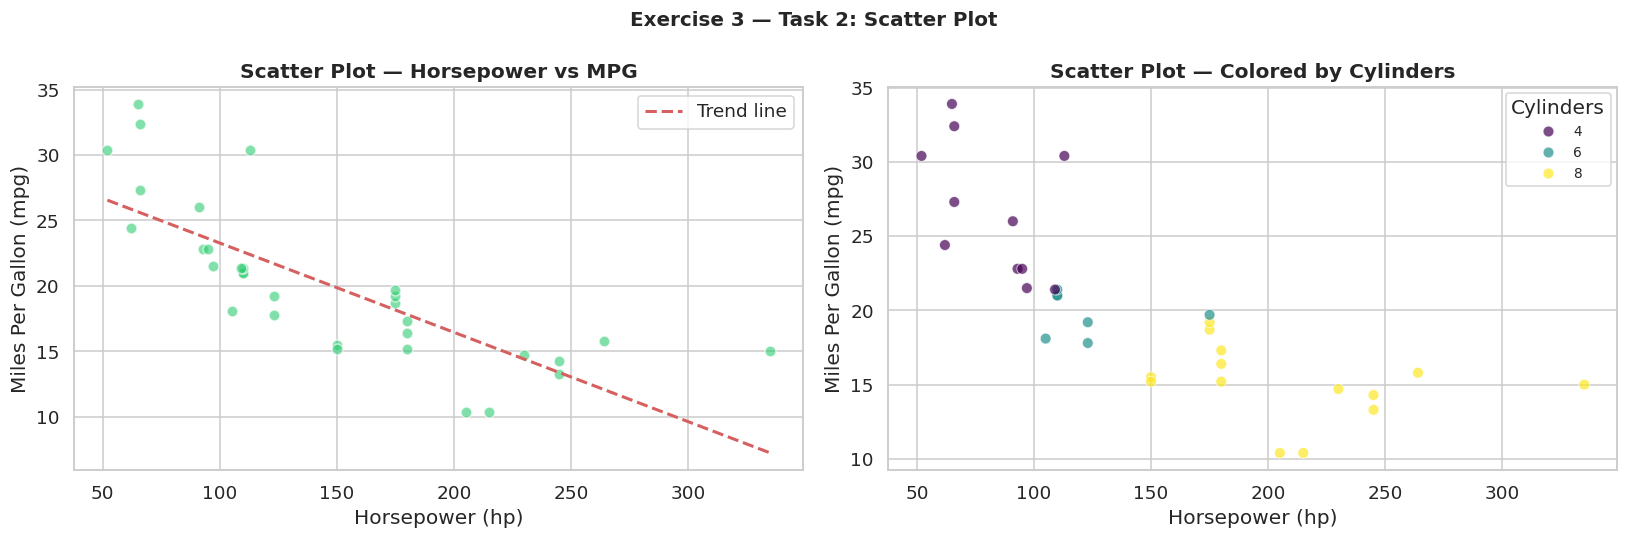

Pearson Correlation (HP vs MPG): -0.776


In [ ]:
df_clean = df.dropna(subset=['hp', 'mpg'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Basic scatter
axes[0].scatter(df_clean['hp'], df_clean['mpg'],
                color='#2ecc71', alpha=0.6, edgecolors='white', s=50)
axes[0].set_title('Scatter Plot — Horsepower vs MPG', fontweight='bold')
axes[0].set_xlabel('Horsepower (hp)'); axes[0].set_ylabel('Miles Per Gallon (mpg)')

# Trend line
z = np.polyfit(df_clean['hp'], df_clean['mpg'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['hp'].min(), df_clean['hp'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')
axes[0].legend()

# Colored by number of cylinders
sns.scatterplot(data=df_clean, x='hp', y='mpg', hue='cyl', palette='viridis',
                alpha=0.7, s=50, edgecolors='white', ax=axes[1])
axes[1].set_title('Scatter Plot — Colored by Cylinders', fontweight='bold')
axes[1].set_xlabel('Horsepower (hp)'); axes[1].set_ylabel('Miles Per Gallon (mpg)')
axes[1].legend(title='Cylinders', fontsize=9)

plt.suptitle('Exercise 3 — Task 2: Scatter Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr = df_clean[['hp','mpg']].corr().iloc[0,1]
print(f'Pearson Correlation (HP vs MPG): {corr:.3f}')

###  Task 3 — Boxplot

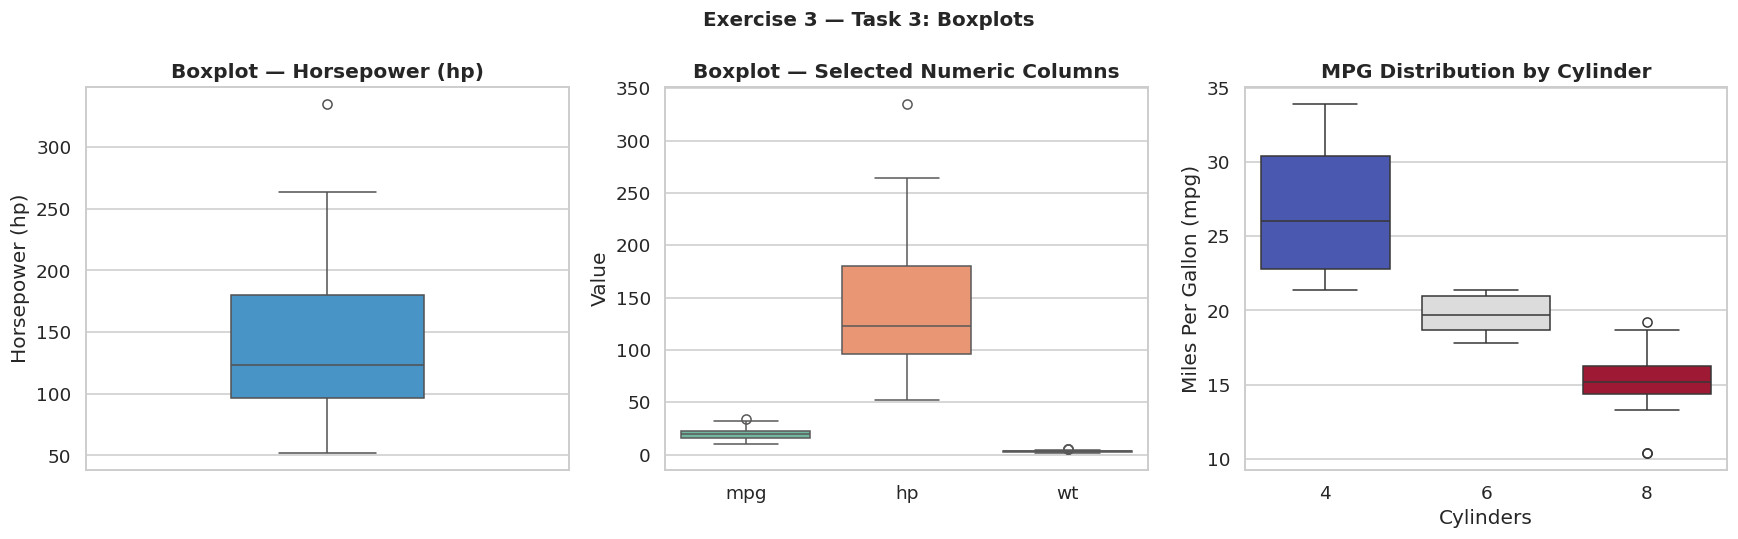

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Single boxplot — Horsepower
sns.boxplot(y=df['hp'].dropna(), ax=axes[0],
            color='#3498db', width=0.4)
axes[0].set_title('Boxplot — Horsepower (hp)', fontweight='bold')
axes[0].set_ylabel('Horsepower (hp)')

# Boxplot — all numeric columns (from mtcars dataset)
num_cols = ['mpg', 'hp', 'wt'] # Updated to use columns from mtcars
df_melt = df[num_cols].melt(var_name='Variable', value_name='Value')
sns.boxplot(data=df_melt, x='Variable', y='Value', hue='Variable', palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Boxplot — Selected Numeric Columns', fontweight='bold')
axes[1].set_xlabel(''); axes[1].set_ylabel('Value')

# Grouped boxplot — MPG by Cylinder count
sns.boxplot(data=df.dropna(subset=['mpg']), x='cyl', y='mpg',
            hue='cyl', palette='coolwarm', ax=axes[2], legend=False) # Changed to mpg by cyl
axes[2].set_title('MPG Distribution by Cylinder', fontweight='bold')
axes[2].set_xlabel('Cylinders'); axes[2].set_ylabel('Miles Per Gallon (mpg)')

plt.suptitle('Exercise 3 — Task 3: Boxplots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [57]:
# Annotate IQR stats
Q1 = df['hp'].quantile(0.25)
Q3 = df['hp'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers    = df[(df['hp'] < lower_fence) | (df['hp'] > upper_fence)]['hp']

print('━'*40)
print(f'  Horsepower Boxplot Statistics:')
print(f'  Min        : {df['hp'].min():.1f}')
print(f'  Q1 (25%)   : {Q1:.1f}')
print(f'  Median     : {df['hp'].median():.1f}')
print(f'  Q3 (75%)   : {Q3:.1f}')
print(f'  Max        : {df['hp'].max():.1f}')
print(f'  IQR        : {IQR:.1f}')
print(f'  Lower Fence: {lower_fence:.1f}')
print(f'  Upper Fence: {upper_fence:.1f}')
print(f'  Outliers   : {len(outliers)}')
print('━'*40)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Horsepower Boxplot Statistics:
  Min        : 52.0
  Q1 (25%)   : 96.5
  Median     : 123.0
  Q3 (75%)   : 180.0
  Max        : 335.0
  IQR        : 83.5
  Lower Fence: -28.8
  Upper Fence: 305.2
  Outliers   : 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [58]:
print("Summary Statistics for 'cyl' column:")
display(df['cyl'].describe())

Summary Statistics for 'cyl' column:


,cyl
count,32.000000
mean,6.187500
std,1.785922
min,4.000000
25%,4.000000
50%,6.000000
75%,8.000000
max,8.000000


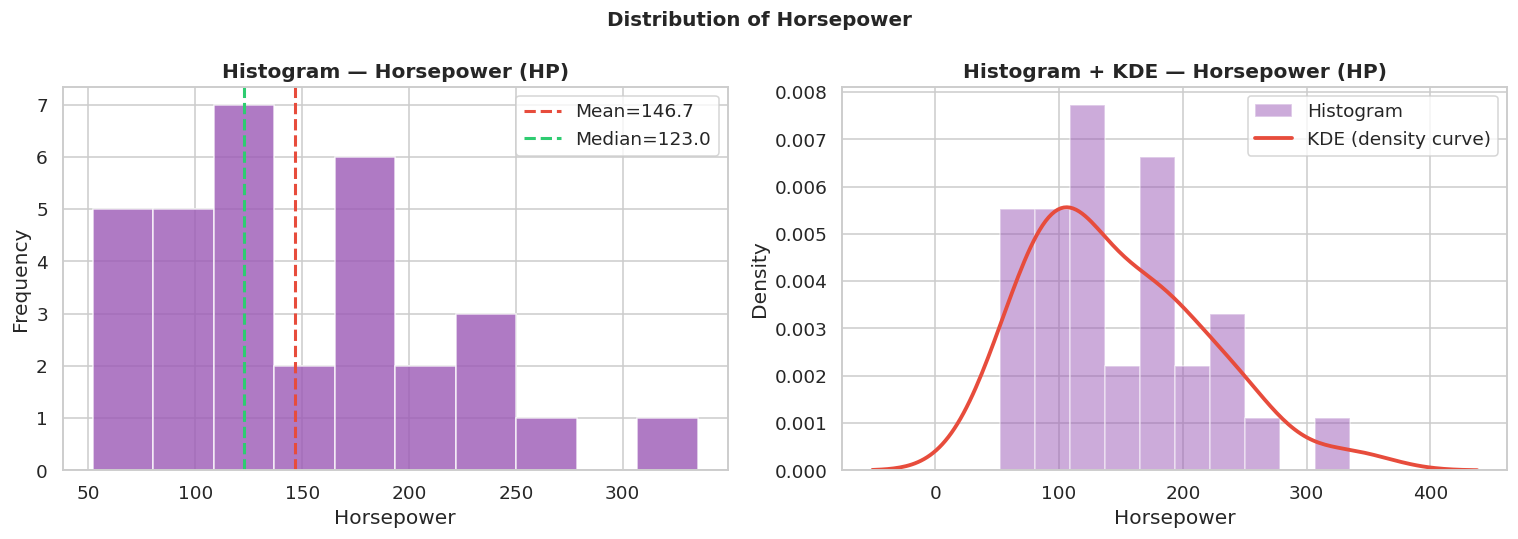

Skewness (HP) : 0.799
Kurtosis (HP) : 0.275


In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Basic histogram of HP
axes[0].hist(df['hp'].dropna(), bins=10, color='#9b59b6',
             alpha=0.8, edgecolor='white')
axes[0].axvline(df['hp'].mean(), color='#e74c3c', linewidth=2,
                linestyle='--', label=f'Mean={df["hp"].mean():.1f}')
axes[0].axvline(df['hp'].median(), color='#2ecc71', linewidth=2,
                linestyle='--', label=f'Median={df["hp"].median():.1f}')
axes[0].set_title('Histogram — Horsepower (HP)', fontweight='bold')
axes[0].set_xlabel('Horsepower'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# KDE overlay of HP
axes[1].hist(df['hp'].dropna(), bins=10, color='#9b59b6',
             alpha=0.5, edgecolor='white', density=True, label='Histogram')
sns.kdeplot(df['hp'].dropna(), ax=axes[1], color='#e74c3c',
            linewidth=2.5, label='KDE (density curve)')
axes[1].set_title('Histogram + KDE — Horsepower (HP)', fontweight='bold')
axes[1].set_xlabel('Horsepower'); axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Distribution of Horsepower', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness (HP) : {df["hp"].skew():.3f}')
print(f'Kurtosis (HP) : {df["hp"].kurtosis():.3f}')

###  Interpretation — Exercise 3

**Histogram:**
| Observation | Interpretation |
|:---|:---|
| Bell-shaped curve | Scores are approximately normally distributed |
| Mean ≈ Median | Symmetric distribution — minimal skew |

**Scatter Plot:**
| Observation | Interpretation |
|:---|:---|
| Positive trend line | Higher attendance slightly associated with higher scores |
| Spread of points | Moderate correlation — other factors also affect scores |

**Boxplot:**
| Part of Box | Meaning |
|:---|:---|
| Bottom whisker | Minimum (excluding outliers) |
| Box bottom (Q1) | 25th percentile |
| Middle line | Median (50th percentile) |
| Box top (Q3) | 75th percentile |
| Top whisker | Maximum (excluding outliers) |
| Dots beyond whiskers | Outliers (beyond 1.5×IQR) |

---

---
#  Final Summary

| Exercise | Topic | Key Skills Practised |
|:---:|:---|:---|
| **1** | NumPy Operations | Matrix creation, row/col aggregation, diagonal extraction |
| **2** | Pandas Manipulation | Data loading, exploration, missing values, sorting |
| **3** | Data Visualization | Histogram, Scatter + trend line, Boxplot + IQR stats |

---

###  Quick Reference Cheat Sheet

```python
# ── NumPy ──────────────────────────────────────────────────────────
np.random.randint(1, 100, size=(4,4))   # random integer matrix
np.sum(matrix, axis=0)                  # column sums
np.sum(matrix, axis=1)                  # row sums
np.diag(matrix)                         # diagonal elements

# ── Pandas ─────────────────────────────────────────────────────────
df.head(10)                             # first 10 rows
df.info()                               # column types
df.describe()                           # summary stats
df.isnull().sum()                       # missing values
df.sort_values(by='col', ascending=False)  # sort

# ── Visualization ──────────────────────────────────────────────────
plt.hist(data, bins=20)                 # histogram
plt.scatter(x, y, alpha=0.6)           # scatter plot
sns.boxplot(x=data)                     # boxplot
sns.heatmap(df.corr(), annot=True)      # correlation heatmap
```

---
*End of Week 1 Lab — Introduction to Statistical Computing*